# **Descriptive Analysis**

## **1. Import libraries**

In [65]:
# import libaries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## **2. Load Dataset**

In [74]:
# Load the dataset and filter unrelated features
df = pd.read_csv("dataset\\digital_marketing_campaign_dataset.csv").drop(columns=["CustomerID", "AdvertisingPlatform", "AdvertisingTool"])
df.head()

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


## **3. Overal Summary and Statistical values**

### **3.1 Checking For Missing Value**

In [67]:
# Check for missing values of each columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                8000 non-null   int64  
 1   Gender             8000 non-null   str    
 2   Income             8000 non-null   int64  
 3   CampaignChannel    8000 non-null   str    
 4   CampaignType       8000 non-null   str    
 5   AdSpend            8000 non-null   float64
 6   ClickThroughRate   8000 non-null   float64
 7   ConversionRate     8000 non-null   float64
 8   WebsiteVisits      8000 non-null   int64  
 9   PagesPerVisit      8000 non-null   float64
 10  TimeOnSite         8000 non-null   float64
 11  SocialShares       8000 non-null   int64  
 12  EmailOpens         8000 non-null   int64  
 13  EmailClicks        8000 non-null   int64  
 14  PreviousPurchases  8000 non-null   int64  
 15  LoyaltyPoints      8000 non-null   int64  
 16  Conversion         8000 non-null   

**Conclusion:** according to the general information of the dataeset, it can be seen that the dataset contains 0 missing value

### **3.2 Checking For Outliers (IQR Method)**

In [68]:

# Detect outliers for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["Conversion"]).columns
outlier_summary = []

for col in numeric_cols:
    # Calculate quantiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate LF and UF
    LF = Q1 - 1.5 * IQR
    UF = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = df[(df[col] < LF) | (df[col] > UF)]

    # Create a dictionary for each variable's outlier
    outlier_summary.append({
        "variable" : col,
        "total outlier" : len(outliers)
    })

# Convert dictionary into Pandas DataFrame
pd.DataFrame(outlier_summary)


,variable,total outlier
0,Age,0
1,Income,0
2,AdSpend,0
3,ClickThroughRate,0
4,ConversionRate,0
5,WebsiteVisits,0
6,PagesPerVisit,0
7,TimeOnSite,0
8,SocialShares,0
9,EmailOpens,0


**Conclusion:** there is no detected outlier in quantitative data

### **3.3 Statistical Values of numerical data**

In [69]:
# statistical values for numerical data
df.describe()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


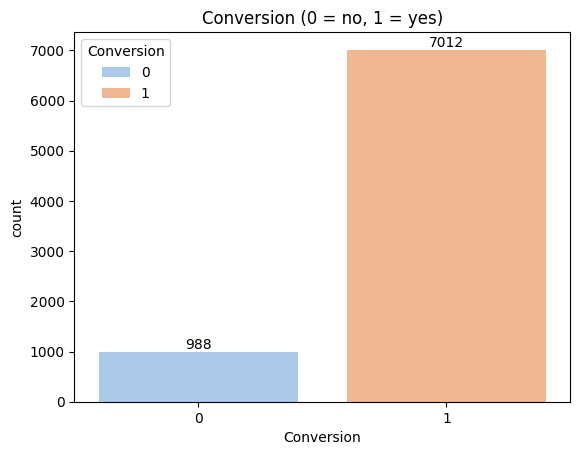

In [70]:
# create a count plot for number of conversion and non-conversion
ax = sns.countplot(data=df, x="Conversion", hue="Conversion", palette="pastel")

# set the title for the plot
plt.title("Conversion (0 = no, 1 = yes)")

# display the number on each bar
for container in ax.containers:
    ax.bar_label(container)


**Conclusion:** the data is heavily imbalanced, the models' performance can be affected.

## **4. Analysis for `Customer` and `Campaign` centrics**

### **4.1 Analysis for customer's demographic and conversion**

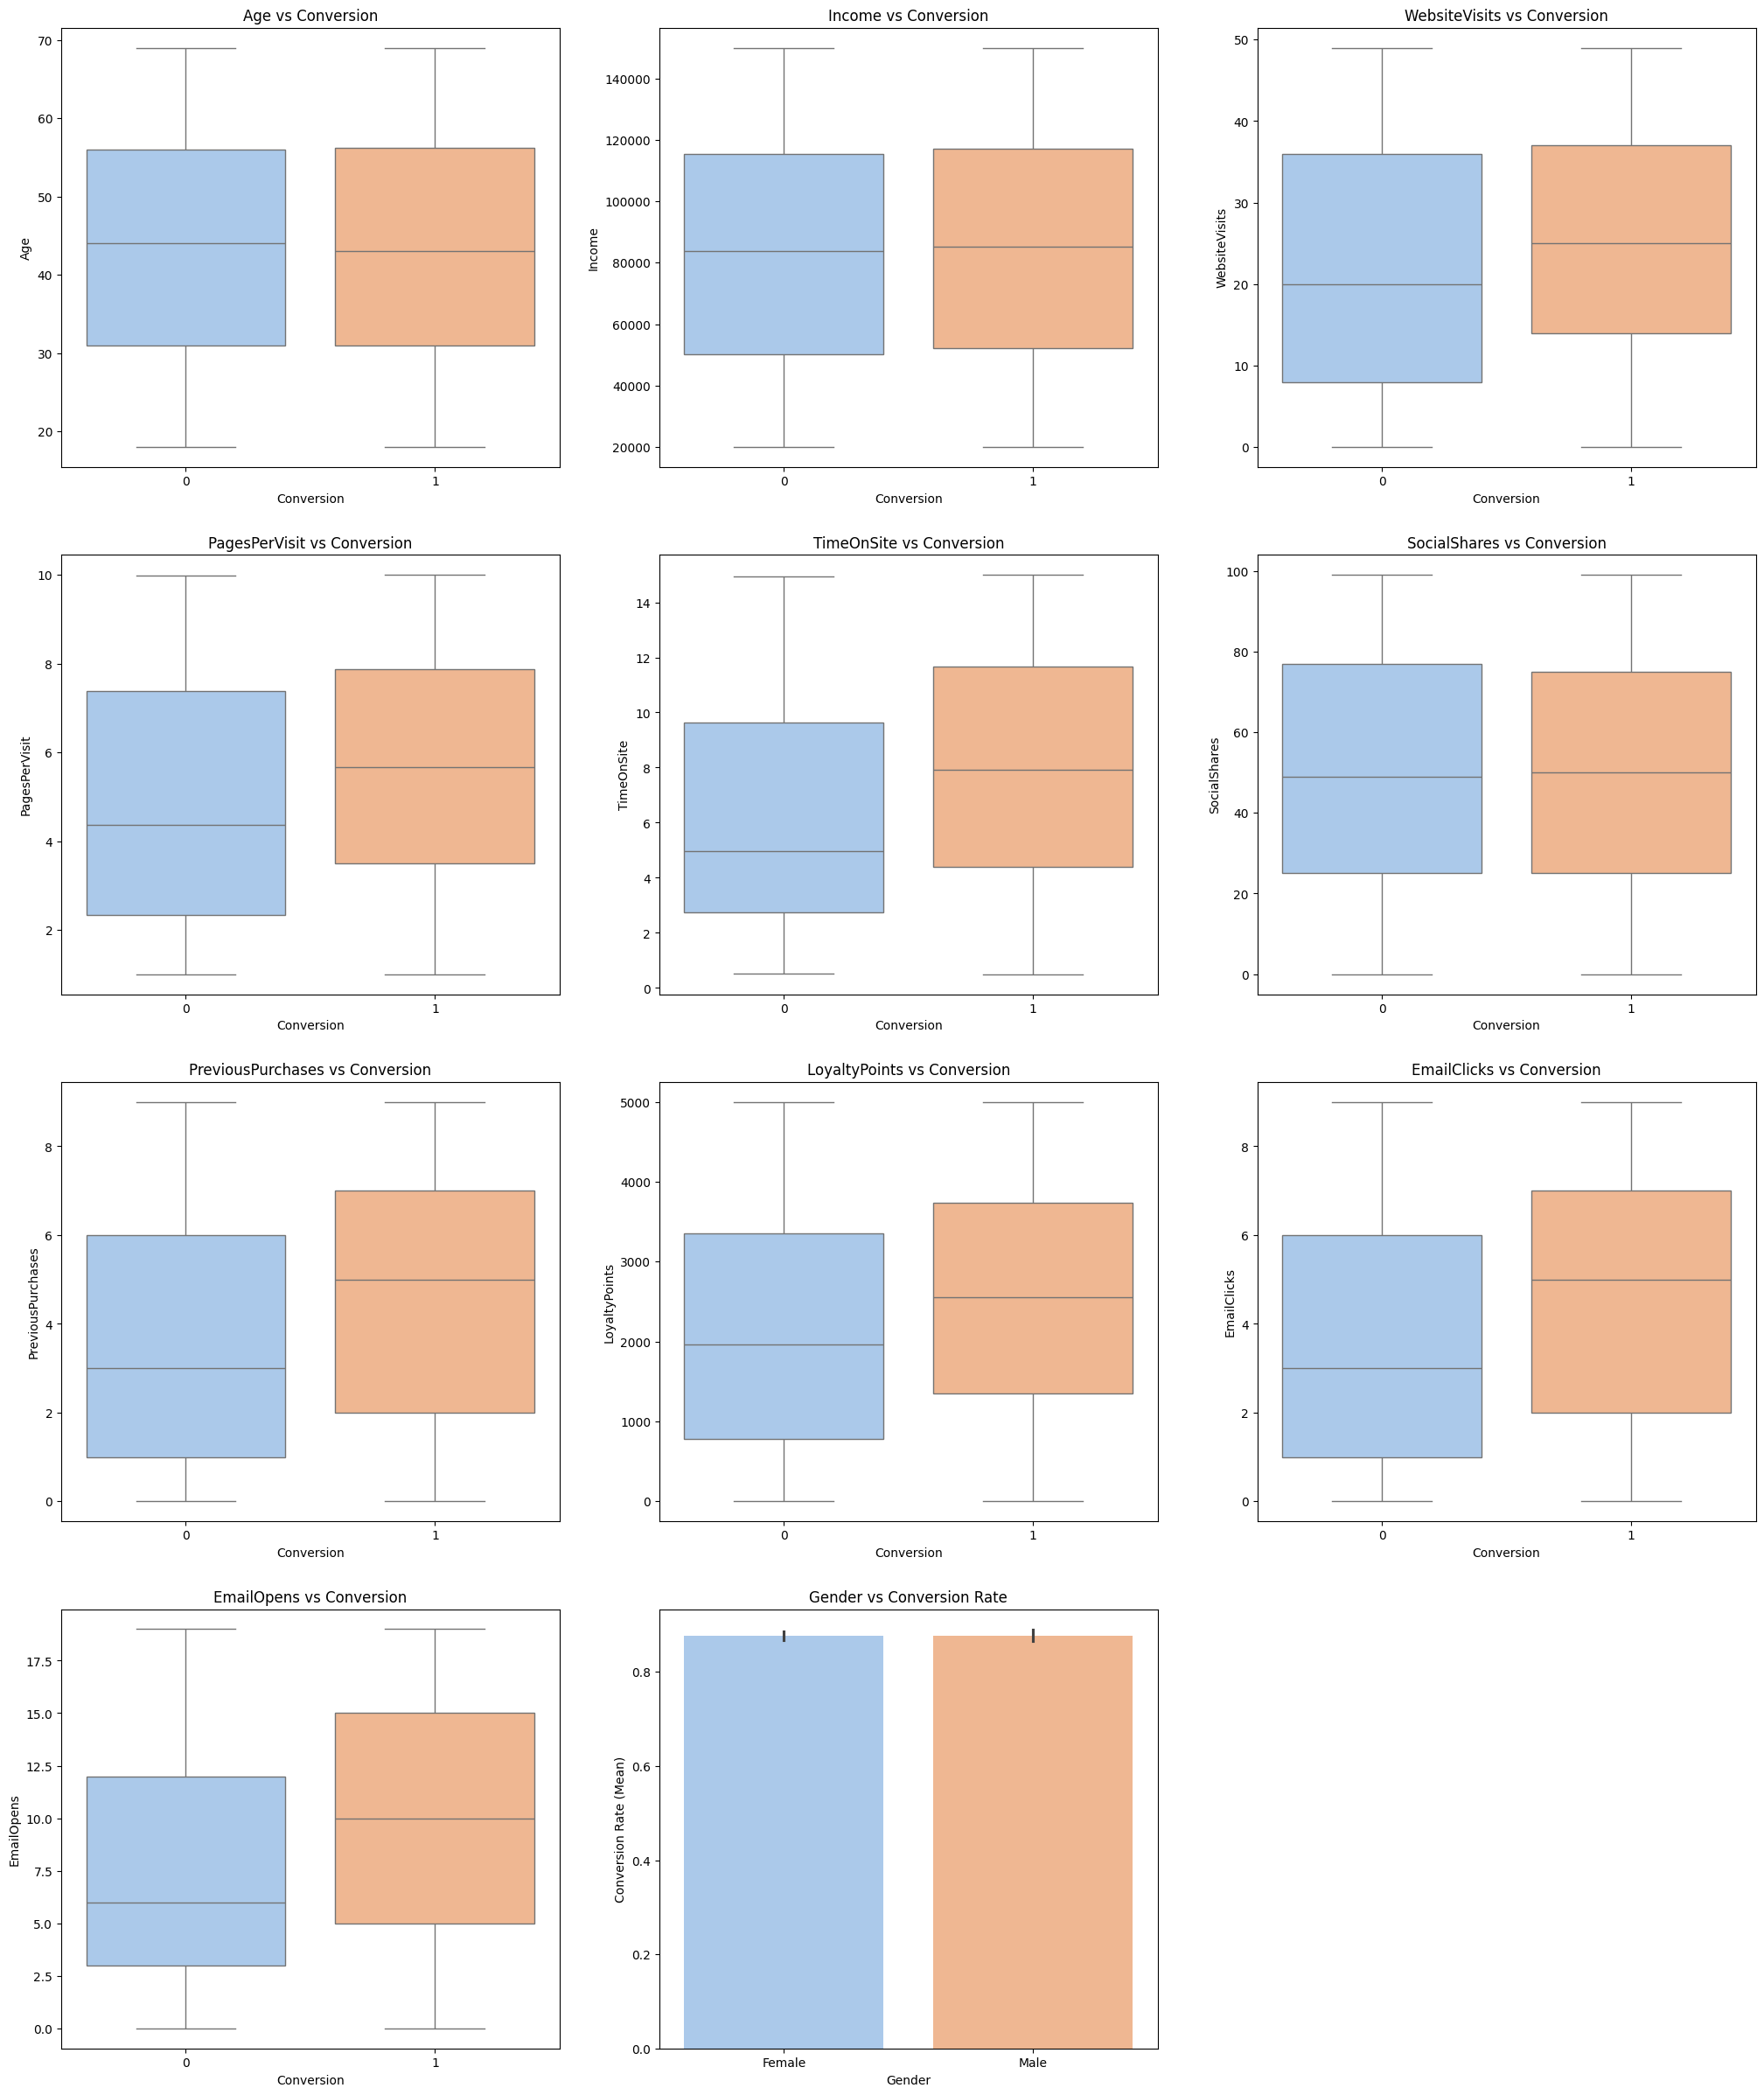

In [ ]:
# Set size for the figure (4 rows, 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(25, 30))
axes = axes.flatten()

# list of customers' demographic and engagement
customer_demographic = [
    "Age", "Income", "WebsiteVisits", "PagesPerVisit", "TimeOnSite", 
    "SocialShares", "PreviousPurchases", "LoyaltyPoints", "EmailClicks", "EmailOpens"
]

# Plot box plot for variables 
for i, v in enumerate(customer_demographic):
    sns.boxplot(data=df, x='Conversion', y=v, ax=axes[i], hue='Conversion', palette="pastel", legend=False)
    
    # set title for box plot 
    axes[i].set_title(f'{v} vs Conversion')
    axes[i].set_xlabel('Conversion')
    axes[i].set_ylabel(v)

# barplot for Gender 
sns.barplot(data=df, x="Gender", y="Conversion", palette="pastel", ax=axes[10])
axes[10].set_title("Gender vs Conversion Rate")
axes[10].set_xlabel("Gender")
axes[10].set_ylabel("Conversion Rate (Mean)")

fig.delaxes(axes[11])
plt.show()

**Conclusion:** <br>
- **Gender:** the countplot reveals that female customers have a significantly higher frequency of conversion, compared to their male partner.

- **Age & Income:** the distribution of age and income are identical, and it gives no insights. Therefore, we should avoid doing further analysis on these two variables.

- **Website Visits:** here is a slightly visible upward shift in the box plot for the converted group. Users who convert tend to have a higher median number of visits.

- **Time On site:** There is a significant difference between two groups. The converted group have a significantly higher time spent on a website in comparision to the non-converted group.

- **Loyalty Point & Previous repurchase:** also shows that loyal customer tend to repond to the marketing campaign

### **4.2 Analysis for Campaign's metrics and conversion**

Text(0.5, 1.0, 'Average CTR by Campaign Channel')

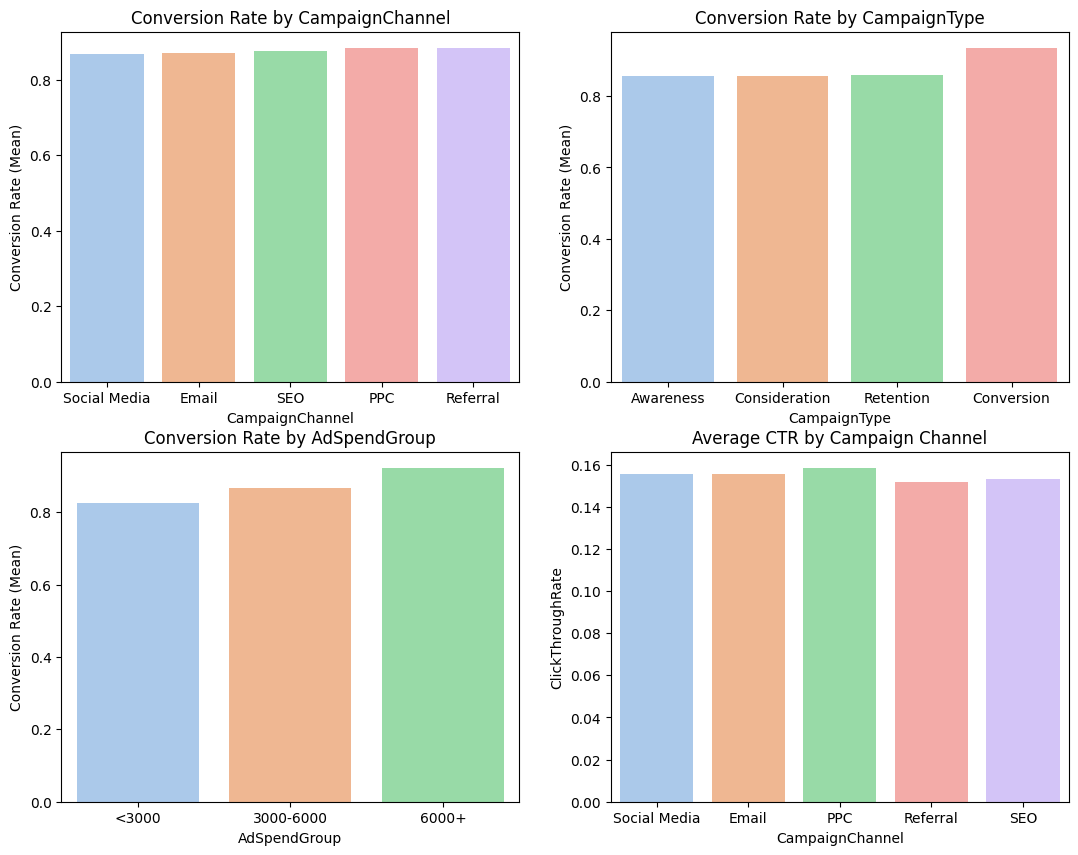

In [72]:
df['AdSpendGroup'] = pd.cut(df['AdSpend'], bins=[0, 3000, 6000, 10000], labels=["<3000", "3000-6000", "6000+"])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()


campaign_metric = ['CampaignChannel', 'CampaignType', 'AdSpendGroup']
for i, v in enumerate(campaign_metric):
    sns.barplot(data=df, x=v, y='Conversion', ax=axes[i], palette="pastel", order=df.groupby(v)['Conversion'].mean().sort_values().index, errorbar=None)
    axes[i].set_title(f'Conversion Rate by {v}')
    axes[i].set_ylabel('Conversion Rate (Mean)')

sns.barplot(data=df, x='CampaignChannel', y='ClickThroughRate', ax=axes[3], 
            palette="pastel", errorbar=None)
axes[3].set_title('Average CTR by Campaign Channel')

**Conclusion:** <br>
- **Campaign Type:** The "Conversion" campaign type has the highest number of successful conversions and the lowest number of non-conversions compared to Awareness or Retention.
- **Campaign channel:** are relatively stable across all channels. However, Referral and PPC show a slight edge in total conversion volume.
- **Ad Spend Group:** There is a clear "Pay-to-win" relationship. The 6000+ spend group has the highest conversion count, while the least invested group received lowest conversion count.

## **5. Heatmap for correlation**

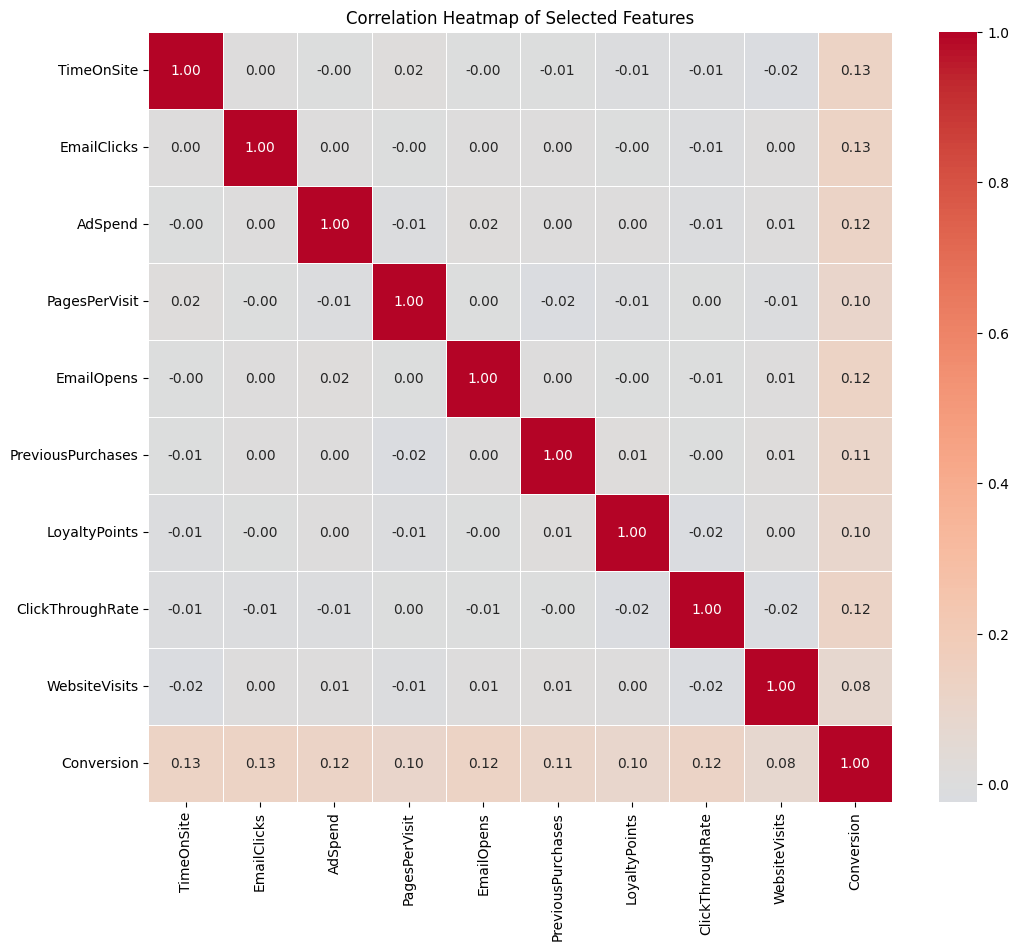

In [77]:
selected_features = [
    'TimeOnSite', 'EmailClicks', 'AdSpend', 'PagesPerVisit', 
    'EmailOpens', 'PreviousPurchases', 'LoyaltyPoints', 
    'ClickThroughRate', 'WebsiteVisits', 'Conversion'
]

df_selected = df[selected_features]
plt.figure(figsize=(12, 10))

sns.heatmap(df_selected.corr(), 
            cmap='coolwarm', 
            annot=True, 
            fmt=".2f", 
            center=0,
            linewidths=0.5)

plt.title('Correlation Heatmap of Selected Features')
plt.show()

**Conclusion:** There is no `Multicollinearity` issue in the selected features. All correlation coefficients between independent variables are very low ($|r| < 0.1$), indicating that the features are independent of each other.

## **6. Summary and Key Insights**

### **Dataset Overview:**
- The dataset contains 8,000 rows and 12 columns after dropping irrelevant features (`CustomerID`, `AdvertisingPlatform`, `AdvertisingTool`).
- No missing values or outliers detected.
- Data is heavily imbalanced (90% non-conversions vs. 10% conversions), which may affect model performance.

### **Key Findings:**
- **Distributions:** Numerical variables are not symmetrically distributed (platykurtic, not normal), with even spread across ranges.
- **Demographic Insights:** Female customers convert more frequently. `Age` and `Income` show no differences between groups.
- **Behavioral Factors:** Higher `WebsiteVisits`, `TimeOnSite`, `LoyaltyPoints`, `PreviousPurchases`, `EmailClicks`, and `ClickThroughRate` correlate with conversions.
- **Campaign Effectiveness:** `Conversion` campaign type performs best. Higher `AdSpend` leads to more conversions. `Referral` and `PPC` channels show slight advantages.
- **Correlations:** No multicollinearity; weak correlations with Conversion (as expected for binary target).